# Data construction

Fella Bouznad, 30/09/2026

623344; MPhil Thesis Business Data Science - Operations Analytics

In [19]:
#change
home = '/Users/fellabouznad/Desktop/thesis_bds'
stata_path = f'{home}/Data/Stata_Annual_Report_Level_20241220_1545.xlsx'
reach_path = f'{home}/Data/Reach_Export_Middelgroot en groter_20230502.xlsx'
bkr_path = f'{home}/Data/Kopie van BKR_Damage_TB_20250224_2230.xlsx'
export_path = f'{home}/Data/data.xlsx'
local_path = "merged_df.xlsx"
report_dir = Path('report_outputs')
report_dir.mkdir(parents=True, exist_ok=True)

In [35]:
#globals
FINANCIAL_DIMENSIONS = ["profitability_distress", "solvency_distress",
    "liquidity_distress", "cashflow_distress", "operations_distress",]

REPORTING_DIMENSIONS = ["reporting_timeliness_distress", "audit_opinion_distress",
    "auditor_switch_distress"]

REACH_MAP = {
    "balanstotaal eur": "reach_ta",
    "eigen vermogen eur": "reach_eq",
    "vlottende activa eur": "reach_ca",
    "kortlopende passiva eur": "reach_cl",
    "liquide middelen eur": "reach_cash",
    "totaal vreemd vermogen eur": "reach_total_liabilities",
    "netto omzet eur": "reach_rev",
    "netto resultaat eur": "reach_ni",
    "bedrijfsresultaat eur": "reach_bi",
}

RATIO_COLS = [
    "roa_clean",
    "leverage_clean",
    "equity_ratio_clean",
    "current_ratio_clean",
    "cash_ratio_clean",
    "working_capital_to_assets_clean",
    "cfo_to_assets_clean",
    "revenue_growth_clean",
    "asset_turnover_clean",
]

VARIABLE_LABELS = {
    'roa_clean': 'Return on assets',
    'leverage_clean': 'Leverage',
    'current_ratio_clean': 'Current ratio',
    'equity_ratio_clean': 'Equity ratio',
    'size': 'Firm size',
    'FDI': 'Dinancial Distress Index',
    'FDI_complete4': 'FDI, complete four-component sample',
    'FDI_without_leverage': 'FDI excluding leverage',
}

bds_purple = "#712F6D"

In [ ]:
#imports
import pandas as pd 
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt 

## Data Merging

In [17]:
#functions
def load_data(stata_path, reach_path, bkr_path):
    'load source files'
    stata_df = pd.read_excel(stata_path) 
    reach_df = pd.read_excel(reach_path, sheet_name=1)
    bkr_df = pd.read_excel(bkr_path)
    return stata_df, reach_df, bkr_df 

def clean_id(series):
    'clean IDs'
    return (
        series.astype("string")
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "<NA>": pd.NA})
    )

def stand_id(stata_df, reach_df, bkr_df):
    'align IDS'
    stata_df = stata_df.copy()
    reach_df = reach_df.copy()
    bkr_df = bkr_df.copy()

    stata_df["bvdid"] = clean_id(stata_df["bvdid"])
    reach_df["bvdid"] = clean_id(reach_df["BvD ID \n nummer"])
    bkr_df["bvdid"] = clean_id(bkr_df["BvDID"])

    stata_df["year"] = pd.to_numeric(stata_df["year"], errors="coerce").astype("Int64")

    stata_df = stata_df.dropna(subset=["bvdid", "year"])
    reach_df = reach_df.dropna(subset=["bvdid"])
    bkr_df = bkr_df.dropna(subset=["bvdid"])

    return stata_df, reach_df, bkr_df

def assert_unique_firm_year(df, name="dataframe"):
    duplicates = df.duplicated(["bvdid", "year"], keep=False)
    if duplicates.any():
        examples = df.loc[duplicates, ["bvdid", "year"]].head(20)
        raise ValueError(
            f"{name} contains duplicate firm-years. Resolve these before analysis.\n"
            f"Examples:\n{examples.to_string(index=False)}"
        )
    

def bankrupt(bkr_df):
    bkr_df = bkr_df.copy()
    bkr_df["BANKRUPTCY_DATE"] = pd.to_datetime(
        bkr_df["BANKRUPTCY_DATE"], errors="coerce"
    )

    valid = bkr_df.dropna(subset=["bvdid", "BANKRUPTCY_DATE"]).copy()

    bkr_event = (
        valid.sort_values(["bvdid", "BANKRUPTCY_DATE"])
        .groupby("bvdid", as_index=False)
        .first()[["bvdid", "BANKRUPTCY_DATE"]]
        .rename(columns={"BANKRUPTCY_DATE": "bankruptcy_date_bkr"})
    )

    bkr_event["bankruptcy_year"] = (
        bkr_event["bankruptcy_date_bkr"].dt.year.astype("Int64")
    )

    return bkr_df, bkr_event

def parse_reach_column(column):
    text = re.sub(r"\s+", " ", str(column).replace("\n", " ")).strip()
    match = re.match(r"^(.*) (20\d{2})(?:\.\d+)?$", text)
    if match is None:
        return None

    label, year = match.groups()
    label = label.strip().lower()
    return label, int(year)

def reshape_reach(reach_df):
    long_parts = []

    for column in reach_df.columns:
        parsed = parse_reach_column(column)
        if parsed is None:
            continue

        label, year = parsed
        if label not in REACH_MAP:
            continue

        value_name = REACH_MAP[label]
        part = reach_df[["bvdid", column]].copy()
        part["year"] = year
        part = part.rename(columns={column: "value"})
        part["value"] = pd.to_numeric(part["value"], errors="coerce")
        part["variable"] = value_name
        long_parts.append(part)

    if not long_parts:
        return pd.DataFrame(columns=["bvdid", "year"])

    reach_stack = pd.concat(long_parts, ignore_index=True)
    reach_stack = (
        reach_stack.groupby(["bvdid", "year", "variable"], as_index=False)["value"]
        .first()
    )

    reach_long = (
        reach_stack.pivot(index=["bvdid", "year"], columns="variable", values="value")
        .reset_index()
    )

    reach_long.columns.name = None
    reach_long["year"] = pd.to_numeric(reach_long["year"], errors="coerce").astype("Int64")

    assert_unique_firm_year(reach_long, "REACH long data")
    return reach_long

def build_firm_year_grid(stata_df, reach_long, expand_internal_gaps=True):
    keys = [stata_df[["bvdid", "year"]].copy()]
    if not reach_long.empty:
        keys.append(reach_long[["bvdid", "year"]].copy())

    observed = pd.concat(keys, ignore_index=True).drop_duplicates()

    if not expand_internal_gaps:
        return observed

    frames = []
    for bvdid, group in observed.groupby("bvdid"):
        min_year = int(group["year"].min())
        max_year = int(group["year"].max())
        frames.append(
            pd.DataFrame(
                {
                    "bvdid": bvdid,
                    "year": pd.array(range(min_year, max_year + 1), dtype="Int64"),
                }
            )
        )

    return pd.concat(frames, ignore_index=True)

def merge_data(stata_df, reach_df, bkr_df, bkr_event, expand_internal_gaps=True):
    stata_df = stata_df.copy()
    reach_df = reach_df.copy()

    assert_unique_firm_year(stata_df, "Annual Report data")

    reach_long = reshape_reach(reach_df)

    stata_df["annual_report_observed"] = 1
    if not reach_long.empty:
        reach_long["reach_record_observed"] = 1

    base = build_firm_year_grid(
        stata_df, reach_long, expand_internal_gaps=expand_internal_gaps
    )

    df = base.merge(
        stata_df,
        on=["bvdid", "year"],
        how="left",
        validate="one_to_one",
    )

    if not reach_long.empty:
        df = df.merge(
            reach_long,
            on=["bvdid", "year"],
            how="left",
            validate="one_to_one",
        )
    else:
        df["reach_record_observed"] = 0

    df = df.merge(
        bkr_event,
        on="bvdid",
        how="left",
        validate="many_to_one",
    )

    df["annual_report_observed"] = df["annual_report_observed"].fillna(0).astype("int8")
    df["reach_record_observed"] = df["reach_record_observed"].fillna(0).astype("int8")
    df["internal_source_gap"] = (
        df["annual_report_observed"].eq(0)
        & df["reach_record_observed"].eq(0)
    ).astype("int8")

    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["bankruptcy_year"] = pd.to_numeric(
        df["bankruptcy_year"], errors="coerce"
    ).astype("Int64")

    # Bankruptcy variables use the FULL BKR outcome date.
    df["bankrupt_event"] = (
        df["year"].eq(df["bankruptcy_year"]).fillna(False).astype("int8")
    )

    # This is deliberately based on a known bankruptcy year, not on whether an
    # event row happens to fall inside the panel.
    df["ever_bankrupt"] = df["bankruptcy_year"].notna().astype("int8")

    df["years_to_bankruptcy"] = df["bankruptcy_year"] - df["year"]
    df["bankruptcy_event_time"] = df["year"] - df["bankruptcy_year"]
    df["pre_bankruptcy_5yr"] = (
        df["bankruptcy_event_time"].between(-5, -1).fillna(False).astype("int8")
    )
    df["at_risk_bankruptcy"] = (
        df["bankruptcy_year"].isna() | df["year"].lt(df["bankruptcy_year"])
    ).astype("int8")

    # Accruals — retain raw variables and add transparent constructions.
    if {"ni", "cfo"}.issubset(df.columns):
        df["total_accruals"] = (
            pd.to_numeric(df["ni"], errors="coerce")
            - pd.to_numeric(df["cfo"], errors="coerce")
        )
    else:
        df["total_accruals"] = np.nan

    if "ta_tmin1" in df.columns:
        df["total_accruals_div_ta"] = (
            df["total_accruals"]
            / pd.to_numeric(df["ta_tmin1"], errors="coerce").replace(0, np.nan)
        )
    else:
        df["total_accruals_div_ta"] = np.nan

    assert_unique_firm_year(df, "merged master panel")
    return df.sort_values(["bvdid", "year"]).reset_index(drop=True)

def num(df, col):
    if col not in df.columns:
        return pd.Series(np.nan, index=df.index, dtype=float)
    return pd.to_numeric(df[col], errors="coerce")


def combine(primary, fallback):
    return primary.combine_first(fallback)


def construct_financial_ratios(df):
    df = df.copy().sort_values(["bvdid", "year"])

    # Amounts used by the five dimensions.
    df["ta_clean"] = combine(num(df, "ta"), num(df, "reach_ta"))
    df["eq_clean"] = combine(num(df, "eq"), num(df, "reach_eq"))
    df["ca_clean"] = combine(num(df, "ca"), num(df, "reach_ca"))
    df["cl_clean"] = combine(num(df, "cl"), num(df, "reach_cl"))
    df["cash_clean"] = combine(num(df, "cash"), num(df, "reach_cash"))
    df["ni_clean"] = combine(num(df, "ni"), num(df, "reach_ni"))

    # rev is preferred to sales; REACH is a final fallback.
    annual_revenue = combine(num(df, "rev"), num(df, "sales"))
    df["rev_clean"] = combine(annual_revenue, num(df, "reach_rev"))

    # CFO is currently available in the Annual Report source.
    df["cfo_clean"] = num(df, "cfo")

    # Use explicit denominators; zero denominator becomes missing.
    ta = df["ta_clean"].replace(0, np.nan)
    cl = df["cl_clean"].replace(0, np.nan)

    # Profitability
    df["roa_clean"] = df["ni_clean"] / ta

    # Solvency / capitalization
    df["equity_ratio_clean"] = df["eq_clean"] / ta

    reach_liabilities = num(df, "reach_total_liabilities")
    reconstructed_liabilities = df["ta_clean"] - df["eq_clean"]
    df["total_liabilities_clean"] = combine(
        reach_liabilities, reconstructed_liabilities
    )
    df["leverage_reconstructed"] = df["total_liabilities_clean"] / ta

    # Keep the source leverage for validation. Use it when available, otherwise
    # use the transparent reconstructed liabilities/assets ratio.
    df["leverage_source"] = num(df, "leverage")
    df["leverage_clean"] = combine(
        df["leverage_source"], df["leverage_reconstructed"]
    )

    # Liquidity
    df["current_ratio_clean"] = df["ca_clean"] / cl
    df["cash_ratio_clean"] = df["cash_clean"] / cl
    df["working_capital_to_assets_clean"] = (
        (df["ca_clean"] - df["cl_clean"]) / ta
    )

    # Cash-flow capacity
    df["cfo_to_assets_clean"] = df["cfo_clean"] / ta

    # Operations
    df["asset_turnover_clean"] = df["rev_clean"] / ta

    lag_revenue = df.groupby("bvdid")["rev_clean"].shift(1)
    lag_year = df.groupby("bvdid")["year"].shift(1)
    consecutive = df["year"].sub(lag_year).eq(1)
    lag_revenue = lag_revenue.where(consecutive)

    df["revenue_growth_clean"] = (
        (df["rev_clean"] - lag_revenue)
        / lag_revenue.abs().replace(0, np.nan)
    )

    return df


def winsorize_within_year(df, variables, year_col="year", lower=0.01, upper=0.99, min_n=20):
    df = df.copy()

    for var in variables:
        if var not in df.columns:
            continue

        def clip_group(x):
            x = pd.to_numeric(x, errors="coerce")
            if x.notna().sum() < min_n:
                return x
            lower_q = x.quantile(lower)
            upper_q = x.quantile(upper)
            return x.clip(lower=lower_q, upper=upper_q)

        df[var + "_w"] = df.groupby(year_col)[var].transform(clip_group)

    return df


def standardize_within_year(df, variables, year_col="year"):
    df = df.copy()

    for var in variables:
        if var not in df.columns:
            continue

        mean = df.groupby(year_col)[var].transform("mean")
        std = df.groupby(year_col)[var].transform("std").replace(0, np.nan)
        df[var + "_z"] = (df[var] - mean) / std

    return df


def row_mean_min(frame, min_nonmissing):
    count = frame.notna().sum(axis=1)
    return frame.mean(axis=1).where(count >= min_nonmissing), count


def construct_financial_dimensions(df):
    """
    Main financial representation = FIVE SEPARATE DIMENSIONS.
    Higher values always mean more distress.

    FDI is retained only as a benchmark summary.
    """
    df = df.copy()

    ratios = [
        "roa_clean",
        "leverage_clean",
        "equity_ratio_clean",
        "current_ratio_clean",
        "cash_ratio_clean",
        "working_capital_to_assets_clean",
        "cfo_to_assets_clean",
        "revenue_growth_clean",
        "asset_turnover_clean",
    ]

    df = winsorize_within_year(df, ratios)
    df = standardize_within_year(df, [f"{v}_w" for v in ratios])

    z = lambda v: f"{v}_w_z"

    # 1. Profitability: high ROA is healthy, so reverse the sign.
    df["profitability_distress"] = -df[z("roa_clean")]

    # 2. Solvency: leverage and capitalization are one conceptual dimension.
    solvency_inputs = pd.DataFrame(
        {
            "leverage_distress": df[z("leverage_clean")],
            "equity_distress": -df[z("equity_ratio_clean")],
        },
        index=df.index,
    )
    # Because these measures can be highly related, one available measure is
    # sufficient for the dimension; n_inputs remains visible for diagnostics.
    df["solvency_distress"], df["solvency_n_inputs"] = row_mean_min(
        solvency_inputs, min_nonmissing=1
    )

    # 3. Liquidity: require at least 2 of 3 measures for the main dimension.
    liquidity_inputs = pd.DataFrame(
        {
            "current_ratio_distress": -df[z("current_ratio_clean")],
            "cash_ratio_distress": -df[z("cash_ratio_clean")],
            "working_capital_distress": -df[z("working_capital_to_assets_clean")],
        },
        index=df.index,
    )
    df["liquidity_distress"], df["liquidity_n_inputs"] = row_mean_min(
        liquidity_inputs, min_nonmissing=2
    )
    df["liquidity_distress_relaxed"], _ = row_mean_min(
        liquidity_inputs, min_nonmissing=1
    )

    # 4. Cash-flow capacity
    df["cashflow_distress"] = -df[z("cfo_to_assets_clean")]

    # 5. Operating performance: strict version requires both measures.
    operations_inputs = pd.DataFrame(
        {
            "revenue_growth_distress": -df[z("revenue_growth_clean")],
            "asset_turnover_distress": -df[z("asset_turnover_clean")],
        },
        index=df.index,
    )
    df["operations_distress"], df["operations_n_inputs"] = row_mean_min(
        operations_inputs, min_nonmissing=2
    )
    df["operations_distress_relaxed"], _ = row_mean_min(
        operations_inputs, min_nonmissing=1
    )

    # Vector completeness — do not silently impute missing dimensions.
    df["financial_vector_n_dimensions"] = (
        df[FINANCIAL_DIMENSIONS].notna().sum(axis=1).astype("int8")
    )
    df["financial_vector_complete_5d"] = (
        df["financial_vector_n_dimensions"].eq(5).astype("int8")
    )

    # FDI is now only a benchmark, not the main representation.
    core_4d = [
        "profitability_distress",
        "solvency_distress",
        "liquidity_distress",
        "cashflow_distress",
    ]
    df["FDI_benchmark_4d"] = (
        df[core_4d].mean(axis=1).where(df[core_4d].notna().sum(axis=1).eq(4))
    )
    df["FDI_benchmark_5d"] = (
        df[FINANCIAL_DIMENSIONS]
        .mean(axis=1)
        .where(df[FINANCIAL_DIMENSIONS].notna().sum(axis=1).eq(5))
    )

    return df

def binary_nullable(df, col):
    if col not in df.columns:
        return pd.Series(pd.NA, index=df.index, dtype="Int8")

    x = pd.to_numeric(df[col], errors="coerce")
    out = pd.Series(pd.NA, index=df.index, dtype="Int8")
    out.loc[x.notna()] = x.loc[x.notna()].ne(0).astype("int8")
    return out


def binary_zero(df, col):
    if col not in df.columns:
        return pd.Series(0, index=df.index, dtype="int8")
    return pd.to_numeric(df[col], errors="coerce").fillna(0).ne(0).astype("int8")


def construct_reporting_dimensions(df):
    df = df.copy()

    # Your actual variables are audit_lag_adopt/sign and audit_late_*.
    delay_continuous = [
        col for col in ["audit_lag_adopt", "audit_lag_sign"] if col in df.columns
    ]

    if delay_continuous:
        for col in delay_continuous:
            df[col + "_clean"] = pd.to_numeric(df[col], errors="coerce")

        df = winsorize_within_year(
            df, [c + "_clean" for c in delay_continuous]
        )
        df = standardize_within_year(
            df, [c + "_clean_w" for c in delay_continuous]
        )

        timing_z = [c + "_clean_w_z" for c in delay_continuous]
        timing_frame = df[timing_z]
        df["reporting_timeliness_distress"], df["reporting_timeliness_n_inputs"] = (
            row_mean_min(timing_frame, min_nonmissing=1)
        )
    else:
        df["reporting_timeliness_distress"] = np.nan
        df["reporting_timeliness_n_inputs"] = 0

    late_flags = [
        "audit_late_adopt",
        "audit_late_sign",
        "audit_too_late_adopt",
        "audit_too_late_sign",
    ]
    available_late_flags = [c for c in late_flags if c in df.columns]
    if available_late_flags:
        late_frame = pd.concat(
            [binary_nullable(df, c) for c in available_late_flags], axis=1
        )
        late_frame.columns = available_late_flags
        df["delayed_filing_event"] = late_frame.fillna(0).max(axis=1).astype("int8")
        df["delay_information_available"] = late_frame.notna().any(axis=1).astype("int8")
    else:
        # Do NOT silently interpret a missing source variable as 'not delayed'.
        df["delayed_filing_event"] = pd.Series(pd.NA, index=df.index, dtype="Int8")
        df["delay_information_available"] = 0

    opinion_inputs = pd.DataFrame(
        {
            "going_concern": binary_nullable(df, "going_concern").astype("Float64"),
            "modified_audit_opinion": binary_nullable(df, "mao").astype("Float64"),
            "high_audit_risk": binary_nullable(df, "High_Audit_Risk").astype("Float64"),
            "high_tca_risk": binary_nullable(df, "High_TCA_Risk").astype("Float64"),
        },
        index=df.index,
    )
    df["audit_opinion_distress"], df["audit_opinion_n_inputs"] = row_mean_min(
        opinion_inputs, min_nonmissing=1
    )

    switch_inputs = pd.DataFrame(
        {
            "lowq_switch_4": binary_nullable(df, "lowq_switch_4").astype("Float64"),
            "lowq_switch_oob": binary_nullable(df, "lowq_switch_oob").astype("Float64"),
            "lowq_ptnr_switch": binary_nullable(df, "lowq_ptnr_switch").astype("Float64"),
        },
        index=df.index,
    )
    df["auditor_switch_distress"], df["auditor_switch_n_inputs"] = row_mean_min(
        switch_inputs, min_nonmissing=1
    )

    df["reporting_vector_n_dimensions"] = (
        df[REPORTING_DIMENSIONS].notna().sum(axis=1).astype("int8")
    )
    df["RDI_benchmark"] = (
        df[REPORTING_DIMENSIONS]
        .mean(axis=1)
        .where(df[REPORTING_DIMENSIONS].notna().sum(axis=1).ge(2))
    )

    # Keep internal gaps separate. They are data-availability diagnostics and
    # are NOT automatically treated as legal non-filing.
    df["reporting_record_gap_exploratory"] = df["internal_source_gap"].astype("int8")

    return df

def first_event_year_from_rows(df, event_col):
    first_year = (
        df.loc[df[event_col].eq(1)]
        .groupby("bvdid")["year"]
        .min()
    )
    return df["bvdid"].map(first_year).astype("Int64")


def min_nullable_year(*series_list):
    frame = pd.concat(
        [pd.to_numeric(s, errors="coerce").astype("Float64") for s in series_list],
        axis=1,
    )
    result = frame.min(axis=1, skipna=True)
    return result.round().astype("Int64")


def add_failure_framework(df):
    df = df.copy()

    # Severe reporting failure = outcome definition; keep OUT of RDI predictors.
    df["severe_reporting_failure_event"] = (
        binary_zero(df, "restatement_362sub6").eq(1)
        | binary_zero(df, "no_mao_restatement").eq(1)
    ).astype("int8")

    df["severe_reporting_failure_year"] = first_event_year_from_rows(
        df, "severe_reporting_failure_event"
    )
    df["ever_severe_reporting_failure"] = (
        df["severe_reporting_failure_year"].notna().astype("int8")
    )

    # Broad reporting incident is descriptive/sensitivity only.
    df["broad_reporting_incident_event"] = (
        df["severe_reporting_failure_event"].eq(1)
        | df["delayed_filing_event"].fillna(0).eq(1)
        | binary_zero(df, "going_concern").eq(1)
        | binary_zero(df, "mao").eq(1)
        | binary_zero(df, "restatement").eq(1)
    ).astype("int8")

    df["broad_reporting_incident_year"] = first_event_year_from_rows(
        df, "broad_reporting_incident_event"
    )
    df["ever_broad_reporting_incident"] = (
        df["broad_reporting_incident_year"].notna().astype("int8")
    )

    # Primary failure year is the EARLIEST of:
    #   - first bankruptcy from full BKR data
    #   - first severe reporting failure in the annual-report data
    df["failure_year"] = min_nullable_year(
        df["bankruptcy_year"],
        df["severe_reporting_failure_year"],
    )

    df["primary_failure_event"] = (
        df["year"].eq(df["failure_year"]).fillna(False).astype("int8")
    )
    df["ever_primary_failure"] = df["failure_year"].notna().astype("int8")

    df["failure_event_time"] = df["year"] - df["failure_year"]
    df["years_to_failure"] = df["failure_year"] - df["year"]
    df["pre_failure_5yr"] = (
        df["failure_event_time"].between(-5, -1).fillna(False).astype("int8")
    )
    df["at_risk_primary_failure"] = (
        df["failure_year"].isna() | df["year"].lt(df["failure_year"])
    ).astype("int8")

    # Broad failure year = first bankruptcy or first broad reporting incident.
    df["broad_failure_year"] = min_nullable_year(
        df["bankruptcy_year"],
        df["broad_reporting_incident_year"],
    )
    df["broad_failure_event"] = (
        df["year"].eq(df["broad_failure_year"]).fillna(False).astype("int8")
    )
    df["ever_broad_failure"] = df["broad_failure_year"].notna().astype("int8")
    df["broad_failure_event_time"] = df["year"] - df["broad_failure_year"]
    df["years_to_broad_failure"] = df["broad_failure_year"] - df["year"]
    df["pre_broad_failure_5yr"] = (
        df["broad_failure_event_time"].between(-5, -1).fillna(False).astype("int8")
    )

    # Compatibility aliases — use explicit variables in new analysis code.
    df["failure"] = df["primary_failure_event"]
    df["ever_failure"] = df["ever_primary_failure"]

    return df

def first_existing_col(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def add_external_effects(df, outcome_col="primary_failure_event", industry_col=None):
    df = df.copy()

    if industry_col is None:
        industry_col = first_existing_col(df, ["sbi_kvk_1", "IND", "industry"])

    df["year_fe"] = df["year"].astype("string")

    if industry_col is None:
        df["industry_fe"] = "unknown"
    else:
        df["industry_fe"] = df[industry_col].astype("string").fillna("unknown")

    df["industry_year_fe"] = df["industry_fe"] + "_" + df["year"].astype("string")

    # Same-year leave-one-out failure rate: descriptive/context variable only.
    group = df.groupby(["industry_fe", "year"])[outcome_col]
    group_sum = group.transform("sum")
    group_count = group.transform("count")

    df["industry_year_failure_rate_loo"] = (
        (group_sum - df[outcome_col]) / (group_count - 1)
    ).replace([np.inf, -np.inf], np.nan)

    # Prediction-safe lagged industry rate.
    industry_year_rate = (
        df.groupby(["industry_fe", "year"], as_index=False)[outcome_col]
        .mean()
        .rename(columns={outcome_col: "industry_failure_rate"})
        .sort_values(["industry_fe", "year"])
    )
    industry_year_rate["industry_failure_rate_lag1"] = (
        industry_year_rate.groupby("industry_fe")["industry_failure_rate"].shift(1)
    )

    df = df.merge(
        industry_year_rate[["industry_fe", "year", "industry_failure_rate_lag1"]],
        on=["industry_fe", "year"],
        how="left",
        validate="many_to_one",
    )

    return df

def make_study_subset(master_df, start_year=2010, end_year=2015):
    df = master_df.loc[master_df["year"].between(start_year, end_year)].copy()

    # Bankruptcy location relative to the selected study window.
    df["bankrupt_before_study"] = (
        df["bankruptcy_year"].lt(start_year).fillna(False).astype("int8")
    )
    df["bankrupt_in_study_window"] = (
        df["bankruptcy_year"].between(start_year, end_year).fillna(False).astype("int8")
    )
    df["bankrupt_after_study"] = (
        df["bankruptcy_year"].gt(end_year).fillna(False).astype("int8")
    )

    # Same distinction for the broader primary-failure definition.
    df["failure_before_study"] = (
        df["failure_year"].lt(start_year).fillna(False).astype("int8")
    )
    df["failure_in_study_window"] = (
        df["failure_year"].between(start_year, end_year).fillna(False).astype("int8")
    )
    df["failure_after_study"] = (
        df["failure_year"].gt(end_year).fillna(False).astype("int8")
    )

    return df.sort_values(["bvdid", "year"]).reset_index(drop=True)

def build_panel(stata_df,reach_df,bkr_df,bkr_event,expand_internal_gaps=True,):
    df = merge_data(
        stata_df=stata_df,
        reach_df=reach_df,
        bkr_df=bkr_df,
        bkr_event=bkr_event,
        expand_internal_gaps=expand_internal_gaps,
    )

    df = construct_financial_ratios(df)
    df = construct_financial_dimensions(df)
    df = construct_reporting_dimensions(df)
    df = add_failure_framework(df)
    df = add_external_effects(
        df,
        outcome_col="primary_failure_event",
    )

    assert_unique_firm_year(df, "final master panel")

    return df.sort_values(["bvdid", "year"]).reset_index(drop=True)

In [ ]:
#main
stata_df, reach_df, bkr_df = load_data(stata_path, reach_path, bkr_path)
stata_df, reach_df, bkr_df = stand_id(stata_df, reach_df, bkr_df)
bkr_df, bkr_event = bankrupt(bkr_df)
merged_df = build_panel(stata_df, reach_df, bkr_df, bkr_event)
merged_df.to_excel(local_path, index=False)

/Users/fellabouznad/anaconda3/envs/deeplfix/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:223: UserWarning: Cell FM23 is marked as a date but the serial value 3077000 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)
/Users/fellabouznad/anaconda3/envs/deeplfix/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:223: UserWarning: Cell FM25 is marked as a date but the serial value 14761000 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)
/Users/fellabouznad/anaconda3/envs/deeplfix/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:223: UserWarning: Cell FM26 is marked as a date but the serial value 12554000 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)
/Users/fellabouznad/anaconda3/envs/deeplfix/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:223: UserWarning: Cell FM27 is marked as a date but the serial value 10868000 is outside the limits for da

## Data Cleaning

In [ ]:
#functions
def clean_panel(df, start_year, end_year):
    df["bvdid"] = df["bvdid"].astype(str).str.strip()
    df["year"] = pd.to_numeric(df["year"], errors="coerce") 
    df = (df.loc[df['year'].between(start_year, end_year)].sort_values(['bvdid', 'year']).copy())

    return df

def binary_col(df, name):
    if name not in df.columns:
        return pd.Series(0, index=df.index, dtype=int)
    
    return (pd.to_numeric(df[name], errors="coerce").fillna(0).astype(int))

def construct_variables(df):
    df["bankrupt_event"] = binary_col(df, "bankrupt_event")

    df["severe_reporting_failure_event"] = (
        (binary_col(df, "restatement_362sub6") == 1) |
        (binary_col(df, "no_mao_restatement") == 1)
    ).astype(int)

    df["primary_failure_event"] = (
        (df["bankrupt_event"] == 1) |
        (df["severe_reporting_failure_event"] == 1)
    ).astype(int)

    for event in [
        "bankrupt_event",
        "severe_reporting_failure_event",
        "primary_failure_event",
    ]:
        ever_name = "ever_" + event.replace("_event", "")

        df[ever_name] = (
            df.groupby("bvdid")[event]
              .transform("max")
              .astype(int)
        )

    first_failure_year = (
            df.loc[df["primary_failure_event"] == 1]
              .groupby("bvdid")["year"]
              .min()
              .rename("primary_failure_year")
        )
    
    df = df.merge(
        first_failure_year,
        left_on="bvdid",
        right_index=True,
        how="left"
        )
    
    df["failure_event_time"] = (
        df["year"] - df["primary_failure_year"]
    )
    
    return df

def numeric(df, name):
    if name not in df.columns:
        return pd.Series(np.nan, index=df.index)

    return pd.to_numeric(df[name], errors="coerce")

def financial_variables(df):
    ta = numeric(df, "ta").replace(0, np.nan)
    ni = numeric(df, "ni")
    eq = numeric(df, "eq")
    ca = numeric(df, "ca")
    cl = numeric(df, "cl").replace(0, np.nan)
    leverage_original = numeric(df, "leverage")

    reach_ta = numeric(df, "reach_ta").replace(0, np.nan)
    reach_ni = numeric(df, "reach_ni")
    reach_eq = numeric(df, "reach_eq")
    reach_ca = numeric(df, "reach_ca")
    reach_cl = numeric(df, "reach_cl").replace(0, np.nan)
    reach_liab = numeric(df, "reach_total_liabilities")

    roa_primary = ni / ta
    roa_reach = reach_ni / reach_ta
    equity_primary = eq / ta
    equity_reach = reach_eq / reach_ta
    liquidity_primary = ca / cl
    liquidity_reach = reach_ca / reach_cl
    leverage_reach = reach_liab / reach_ta

    df["roa_clean"] = roa_primary.combine_first(roa_reach)
    df["equity_ratio_clean"] = (
            equity_primary.combine_first(equity_reach)
        )
    df["current_ratio_clean"] = (
            liquidity_primary.combine_first(liquidity_reach)
        )
    df["leverage_clean"] = (
            leverage_original.combine_first(leverage_reach)
        )

    df["roa_source"] = np.select(
            [
                roa_primary.notna(),
                roa_reach.notna()
            ],
            [
                "main",
                "reach"
            ],
            default="missing"
        )
    
    df["equity_source"] = np.select(
            [
                equity_primary.notna(),
                equity_reach.notna()
            ],
            [
                "main",
                "reach"
            ],
            default="missing"
        )
    
    df["liquidity_source"] = np.select(
            [
                liquidity_primary.notna(),
                liquidity_reach.notna()
            ],
            [
                "main",
                "reach"
            ],
            default="missing"
        )
    
    df["leverage_source_final"] = np.select(
            [
                leverage_original.notna(),
                leverage_reach.notna()
            ],
            [
                "main",
                "reach"
            ],
            default="missing"
        )
    
    return df

def winsorize(x, lower=0.01, upper=0.99):
    x = x.copy()
    nonmissing = x.dropna()
    if len(nonmissing) == 0:
        return x
    lower_value = nonmissing.quantile(lower)
    upper_value = nonmissing.quantile(upper)
    return x.clip(lower_value, upper_value)

def winsorize_df(df):
    fdi_raw_variables = [
            "roa_clean",
            "leverage_clean",
            "current_ratio_clean",
            "equity_ratio_clean"
        ]

    for variable in fdi_raw_variables:
            df[f"{variable}_w"] = winsorize(df[variable])

    return df

def year_zscore(data, variable):
    mean = data.groupby("year")[variable].transform("mean")
    std = data.groupby("year")[variable].transform("std")
    std = std.replace(0, np.nan)
    return (data[variable] - mean) / std

def distress(df):
    df["profitability_distress_z"] = (
            -year_zscore(df, "roa_clean_w")
        )
    
    df["leverage_distress_z"] = (
            year_zscore(df, "leverage_clean_w")
        )
    
    df["liquidity_distress_z"] = (
            -year_zscore(df, "current_ratio_clean_w")
        )
    
    df["equity_distress_z"] = (
            -year_zscore(df, "equity_ratio_clean_w")
        )
    return df 

def fdi_build(df):
    fdi_components = [
            "profitability_distress_z",
            "leverage_distress_z",
            "liquidity_distress_z",
            "equity_distress_z"
        ]
    
    df["FDI_n_components"] = (
            df[fdi_components]
            .notna()
            .sum(axis=1)
        )
    
    df["FDI"] = (
            df[fdi_components]
            .mean(axis=1, skipna=True)
        )
    
    df.loc[df["FDI_n_components"] < 3, "FDI"] = np.nan
    
    df["FDI_complete4"] = (
            df[fdi_components]
            .mean(axis=1)
        )
    
    df.loc[
            df["FDI_n_components"] != 4,
            "FDI_complete4"
        ] = np.nan
    
    return df

def analysis_variables(df):
    if "annual_report_observed" in df.columns:
        df["annual_report_observed"] = (
                pd.to_numeric(
                    df["annual_report_observed"],
                    errors="coerce"
                )
            )
    
        df["annual_report_missing"] = (
                df["annual_report_observed"]
                .eq(0)
                .astype(int)
            )
    
    if "reach_record_observed" in df.columns:
            df["reach_record_observed"] = (
                pd.to_numeric(
                    df["reach_record_observed"],
                    errors="coerce"
                )
            )
    
    for variable in [
            "delayed_filing_event",
            "delay_information_available",
            "reporting_timeliness_distress"
        ]:
        if variable in df.columns:
            df[variable] = pd.to_numeric(
                    df[variable],
                    errors="coerce"
                )

    df["has_main_FDI"] = df["FDI"].notna().astype(int)
    df["has_complete_FDI"] = (
            df["FDI_complete4"].notna().astype(int)
        )
    
        # Number of usable FDI years per firm.
    df["firm_FDI_years"] = (
            df.groupby("bvdid")["FDI"]
              .transform("count")
        )
    
        # Do NOT automatically drop incomplete firms.
        # Use this as a robustness sample if needed.
    df["complete_6yr_FDI_panel"] = (
            df["firm_FDI_years"] == 6
        ).astype(int)

    lag_variables = [
            "FDI",
            "roa_clean",
            "leverage_clean",
            "current_ratio_clean",
            "equity_ratio_clean",
            "size"
        ]
    
    for variable in lag_variables:
        if variable in df.columns:
            df[f"{variable}_lag1"] = (
                    df.groupby("bvdid")[variable]
                      .shift(1)
                )
    
    return df

def build_analysis_df(merged_df, start_year=2010, end_year=2015):
    df = merged_df.copy()
    df = clean_panel(df, start_year, end_year)
    df = construct_variables(df)
    df = financial_variables(df)
    df = winsorize_df(df)
    df = distress(df)
    df = fdi_build(df)
    df = analysis_variables(df)
    df = (df.sort_values(["bvdid", "year"]).reset_index(drop=True))
    return df

In [ ]:
#main
merged_df = pd.read_excel(local_path) 
df = build_analysis_df(merged_df)

## Data Matching

In [61]:
#functions
def save_report_table(df, filename, caption=None, label=None, float_format="%.3f"):
    csv_path = report_dir / f"{filename}.csv"
    tex_path = report_dir / f"{filename}.tex"

    df.to_csv(csv_path, index=False)

    latex = df.to_latex(
        index=False,
        escape=True,
        float_format=float_format,
        caption=caption,
        label=label,
    )
    tex_path.write_text(latex, encoding="utf-8")

    return csv_path, tex_path

def make_sample_construction_table(merged_df, df):
    rows = []
    rows.append({
        'Sample': 'Study-period panel (2010-2015)',
        'Firms': int(df["bvdid"].nunique()),
        'Firm-year observations': int(len(df))
    })

    fdi_df = df.loc[df['FDI'].notna()]
    rows.append({
            'Sample': 'Firm-years with FDI (>=3 of 4 components)',
            'Firms': int(fdi_df["bvdid"].nunique()),
            'Firm-year observations': int(len(fdi_df))
        })

    complete_df = df.loc[df['FDI_complete4'].notna()]
    rows.append({
                'Sample': 'Firm-years with complete four-component FDI',
                'Firms': int(complete_df["bvdid"].nunique()),
                'Firm-year observations': int(len(complete_df))
            })

    return pd.DataFrame(rows)

def make_failure_incidence_table(df):
    outcome_map = {
        'bankrupt_event': 'Bankruptcy',
        'severe_reporting_failure_event': 'Severe reporting failure',
        'primary_failure_event': 'Primary failure',
    }
    n_firms = df['bvdid'].nunique()
    rows = []

    for col, label in outcome_map.items():
        if col not in df.columns:
            continue
        event = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
        event_firms = df.loc[event.eq(1), 'bvdid'].nunique()
        event_rows = int(event.sum())

        rows.append({
            'Outcome': label,
            'Firms with event': int(event_firms),
            'Firm share %': 100 * event_firms / n_firms,
            'Event-year observations': event_rows,
        })

    return pd.DataFrame(rows)

def make_variable_definition_table():
    return pd.DataFrame([
        {
            "Variable": "roa_clean",
            "Concept": "Profitability",
            "Definition": "Net income / total assets; Annual Report source preferred, REACH ratio used as fallback.",
            "Role": "FDI component (sign reversed)",
        },
        {
            "Variable": "leverage_clean",
            "Concept": "Solvency",
            "Definition": "Leverage from Annual Report data; REACH total liabilities / total assets used as fallback.",
            "Role": "FDI component",
        },
        {
            "Variable": "current_ratio_clean",
            "Concept": "Liquidity",
            "Definition": "Current assets / current liabilities; constructed within source before fallback.",
            "Role": "FDI component (sign reversed)",
        },
        {
            "Variable": "equity_ratio_clean",
            "Concept": "Capitalization",
            "Definition": "Equity / total assets; Annual Report source preferred, REACH ratio used as fallback.",
            "Role": "FDI component (sign reversed)",
        },
        {
            "Variable": "FDI",
            "Concept": "Financial distress",
            "Definition": "Mean of the available year-standardized distress components; at least 3 of 4 required.",
            "Role": "Main composite distress measure",
        },
        {
            "Variable": "FDI_complete4",
            "Concept": "Financial distress",
            "Definition": "Same FDI construction, restricted to firm-years with all four components.",
            "Role": "Missingness robustness check",
        },
        {
            "Variable": "FDI_without_leverage",
            "Concept": "Financial distress",
            "Definition": "Mean of profitability, liquidity, and capitalization distress; at least 2 of 3 required.",
            "Role": "Leverage-dominance robustness check",
        },
        {
            "Variable": "primary_failure_event",
            "Concept": "Failure",
            "Definition": "One in a firm-year with bankruptcy or a severe reporting failure.",
            "Role": "Main empirical outcome",
        },
        {
            "Variable": "severe_reporting_failure_event",
            "Concept": "Reporting failure",
            "Definition": "Article 362(6) restatement or restatement without a modified audit opinion.",
            "Role": "Component of primary failure",
        },
        {
            "Variable": "annual_report_missing",
            "Concept": "Data availability",
            "Definition": "One when the Annual Report record is not observed for a firm-year on the merged grid.",
            "Role": "Missingness diagnostic; not treated as failure",
        },
        {
            "Variable": "delayed_filing_event",
            "Concept": "Reporting timeliness",
            "Definition": "Observed late/too-late filing indicator where filing-delay information is available.",
            "Role": "Separate reporting diagnostic; not included in main FDI",
        },
    ])

def make_missingness_table(df):
    candidates = ['roa_clean', 'leverage_clean', 'current_ratio_clean', 'equity_ratio_clean', 'FDI', 'FDI_complete4', 'FDI_without_leverage',]
    rows = []
    n = len(df)

    for col in candidates:
        if col not in df.columns:
            continue 
        missing_n = int(df[col].isna().sum())
        rows.append({
            'Variable': VARIABLE_LABELS.get(col,col),
            'Available N': int(n-missing_n),
            'Missing N': missing_n,
            'Missing %': 100 * missing_n / n
        })

    return pd.DataFrame(rows)

def make_data_availability_table(analysis_df):
    rows = []
    n = len(analysis_df)

    def add_binary_metric(label, col, conditional_col=None):
        if col not in analysis_df.columns:
            return

        x = pd.to_numeric(analysis_df[col], errors="coerce")

        if conditional_col is None:
            eligible = x.notna()
        else:
            eligible = pd.to_numeric(
                analysis_df[conditional_col], errors="coerce"
            ).eq(1) & x.notna()

        denom = int(eligible.sum())
        positive = int(x.loc[eligible].eq(1).sum()) if denom else 0

        rows.append({
            "Diagnostic": label,
            "Positive / observed N": positive,
            "Denominator N": denom,
            "Share (%)": 100 * positive / denom if denom else np.nan,
        })

    add_binary_metric("Annual Report record observed", "annual_report_observed")
    add_binary_metric("REACH record observed", "reach_record_observed")
    add_binary_metric("Internal source gap", "internal_source_gap")
    add_binary_metric("Main FDI available", "has_main_FDI")
    add_binary_metric("Complete four-component FDI available", "has_complete_FDI")
    add_binary_metric("Filing-delay information available", "delay_information_available")
    add_binary_metric(
        "Delayed filing, conditional on delay information",
        "delayed_filing_event",
        conditional_col="delay_information_available",
    )

    return pd.DataFrame(rows)

def make_fdi_table(df):
    counts = (df['FDI_n_components'].value_counts(dropna=False).sort_index())
    total = counts.sum()

    return pd.DataFrame({
        'Number of available FDI components': counts.index.astype(str),
        'Firm-year observations': counts.values.astype(int),
        'Share %': 100 * counts.values / total
    })

def make_descriptive_table(analysis_df):
    variables = [
        "roa_clean",
        "leverage_clean",
        "current_ratio_clean",
        "equity_ratio_clean",
        "size",
        "FDI",
    ]
    variables = [v for v in variables if v in analysis_df.columns]

    rows = []
    group_map = {
        0: "No primary failure",
        1: "Primary failure",
    }

    for variable in variables:
        row = {
            "Variable": VARIABLE_LABELS.get(variable, variable)
        }

        for g, label in group_map.items():
            values = (
                analysis_df.loc[
                    analysis_df["ever_primary_failure"].eq(g),
                    variable
                ]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
                .astype(float)
            )

            prefix = "No failure" if g == 0 else "Failure"
            row[f"{prefix} N"] = int(values.size)
            row[f"{prefix} Mean"] = values.mean()
            row[f"{prefix} Std."] = values.std(ddof=1)
            row[f"{prefix} P25"] = values.quantile(0.25)
            row[f"{prefix} Median"] = values.median()
            row[f"{prefix} P75"] = values.quantile(0.75)

        rows.append(row)

    return pd.DataFrame(rows)

def make_fdi_component_correlation_table(analysis_df):
    components = {
        "profitability_distress_z": "Profitability distress",
        "leverage_distress_z": "Leverage distress",
        "liquidity_distress_z": "Liquidity distress",
        "equity_distress_z": "Capitalization distress",
    }

    rows = []
    for col, label in components.items():
        if col not in analysis_df.columns:
            continue

        pair = analysis_df[["FDI", col]].replace([np.inf, -np.inf], np.nan).dropna()
        corr = pair["FDI"].corr(pair[col]) if len(pair) >= 2 else np.nan

        rows.append({
            "FDI component": label,
            "Correlation with FDI": corr,
            "Pairwise N": int(len(pair)),
        })

    return pd.DataFrame(rows)

def make_financial_correlation_matrix(analysis_df):
    cols = [
        "roa_clean",
        "leverage_clean",
        "current_ratio_clean",
        "equity_ratio_clean",
        "FDI",
    ]
    cols = [c for c in cols if c in analysis_df.columns]

    corr = (
        analysis_df[cols]
        .replace([np.inf, -np.inf], np.nan)
        .corr()
        .rename(index=VARIABLE_LABELS, columns=VARIABLE_LABELS)
        .reset_index()
        .rename(columns={"index": "Variable"})
    )
    return corr

def make_source_coverage_table(analysis_df):
    source_map = {
        "roa_source": "ROA",
        "leverage_source_final": "Leverage",
        "liquidity_source": "Current ratio",
        "equity_source": "Equity ratio",
    }
    rows = []

    for col, label in source_map.items():
        if col not in analysis_df.columns:
            continue

        shares = analysis_df[col].fillna("missing").value_counts(dropna=False)
        total = shares.sum()

        for source, count in shares.items():
            rows.append({
                "Ratio": label,
                "Source": str(source),
                "Firm-year observations": int(count),
                "Share (%)": 100 * count / total if total else np.nan,
            })

    return pd.DataFrame(rows)

'''def plot_fdi_distribution(df, save_path=None):
    fig, ax = plt.subplots()

    df_non = df[df['ever_failure'] == 0]['FDI'].dropna()
    df_bank = df[df['ever_failure'] == 1]['FDI'].dropna()

    ax.hist(
        df_non,
        bins=50,
        density=True,
        alpha=0.5,
        label='Non-bankrupt',
        color='gray'
    )

    ax.hist(
        df_bank,
        bins=50,
        density=True,
        alpha=0.5,
        label='Bankrupt',
        color=bds_purple
    )

    ax.set_xlabel("Financial Distress Index (higher = greater distress)")
    ax.set_ylabel("Density")
    ax.set_title(
        "Distribution of the Financial Distress Index by primary-failure status"
    )

    ax.legend()
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
'''

def plot_fdi_distribution(df, save_path=None):
    fig, ax = plt.subplots()

    # Plasma color palette
    cmap = plt.get_cmap('plasma')
    non_failure_color = cmap(0.25)   # dark purple
    failure_color = cmap(0.75)       # orange/pink

    df_non = df[df['ever_failure'] == 0]['FDI'].dropna()
    df_bank = df[df['ever_failure'] == 1]['FDI'].dropna()

    ax.hist(
        df_non,
        bins=50,
        density=True,
        alpha=0.55,
        label='Non-failure',
        color=non_failure_color
    )

    ax.hist(
        df_bank,
        bins=50,
        density=True,
        alpha=0.55,
        label='Primary-failure',
        color=failure_color
    )

    ax.set_xlabel("Financial Distress Index (higher = greater distress)")
    ax.set_ylabel("Density")
    ax.set_title(
        "Distribution of the Financial Distress Index by Primary-Failure Status"
    )

    ax.legend()
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    
def plot_fdi_component_coverage_by_year(analysis_df, save_path=None):
    coverage = (
        analysis_df.groupby(["year", "FDI_n_components"])
        .size()
        .rename("n")
        .reset_index()
    )

    coverage["share"] = (
        coverage["n"]
        / coverage.groupby("year")["n"].transform("sum")
    )

    pivot = (
        coverage.pivot(
            index="year",
            columns="FDI_n_components",
            values="share"
        )
        .fillna(0)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=["#D9C4D7", "#B987B5", "#92518E", "#712F6D"],
    )

    ax.set_title("Availability of FDI components by year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Share of firm-year observations")
    ax.legend(
        title="Available components",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    ax.grid(axis="y", alpha=0.2)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig

def build_data_outputs(merged_df, df):
    tables = {
        'table_31_sample_construction': (make_sample_construction_table(merged_df, df),
                                         'Sample construction for the Dutch accounting panel.', 'tab:sample_construction',),
        'table_32_failure_incidence': (make_failure_incidence_table(df), 
                                       'Indidence of bankruptcy and reporting-failure outcomes in the 2010-2015 sample.', 'tab:failure_incidence',),
        'table_33_variable_definitions': (make_variable_definition_table(),
                                          'Definition and role of the main empirical variables.', 'tab:variable_definitions'),
        'table_34_missingness': (make_missingness_table(df),
                                 'Availability and missingness of the main variables', 'tab:missingness'),
        'table_35_data_availability': (make_data_availability_table(df),
                                       'Source availability, FDI availability, and observed filing-delay information.', 'tab: data_availability'),
        'table_36_fdi_component_coverage': (make_fdi_table(df),
                                            'Number of available FDI components per firm-year', 'tab:fdi_component_coverage'),
        'table_37_descriptives': (make_descriptive_table(df),
                                  'Descriptive statistics by firm-level primary-failure status', 'tab:descriptives'),
        'table_38_fdi_component_correlations': (make_fdi_component_correlation_table(df),
                                                'Pairwise correlations between the FDI and its components.', 'tab:fdi_component_correlations'),
        'table_39_financial_correlations': (make_financial_correlation_matrix(df),
                                            'Correlation matrix of the main financial variables.', 'tab:financial_correlations'),
        'appendix_source_coverage': (make_source_coverage_table(df),
                                     'Source coverage for the financial ratios used in the empirical analysis.', 'tab:source_coverage'),
    }

    for filename, (table, caption, label) in tables.items(): 
        save_report_table(table, filename, caption=caption, label=label,)

    fig1 = plot_fdi_distribution(
        df, save_path= report_dir / 'figure_31_fdi_distribution.png', 
    )
    plt.close(fig1)

    fig2 = plot_fdi_component_coverage_by_year(
        df, save_path= report_dir / 'figure_32_fdi_component_coverage_by_year.png', 
    )
    plt.close(fig2)

    print(f"Saved Section 3.1 tables and figures to: {report_dir.resolve()}")

    return {name: item[0] for name, item in tables.items()}

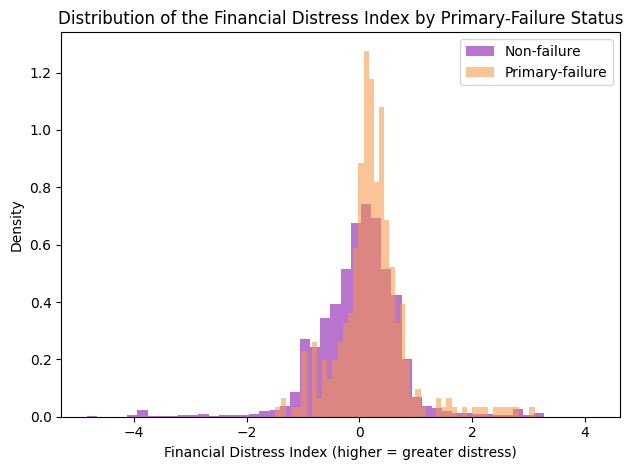

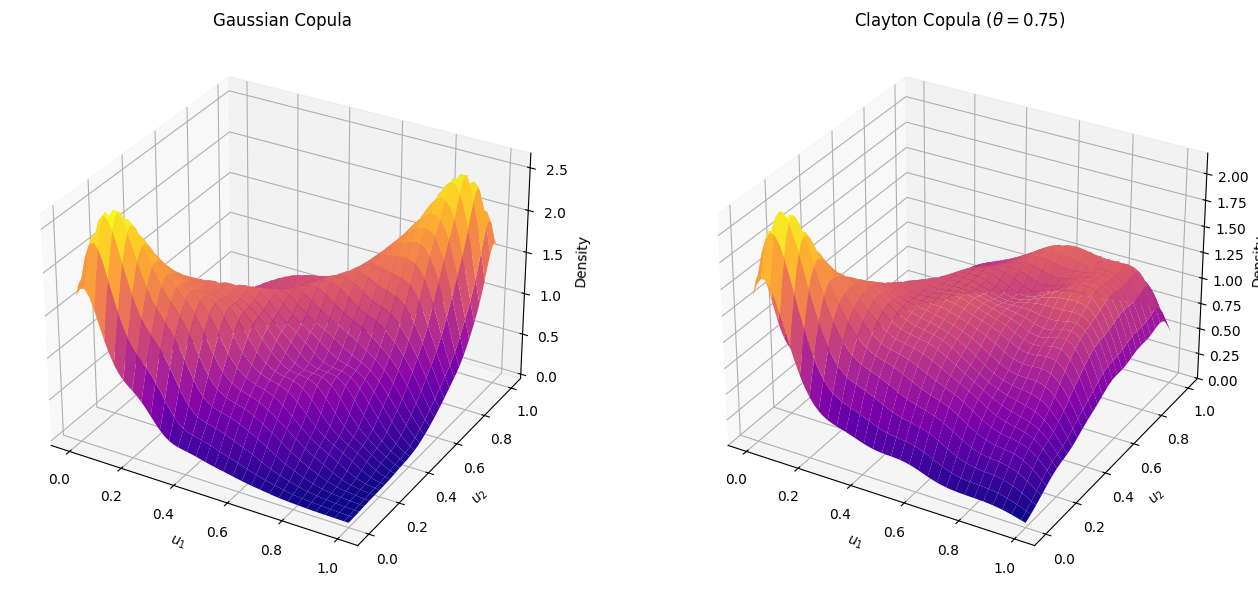

Saved Section 3.1 tables and figures to: /Users/fellabouznad/Desktop/thesis_bds/report_outputs


In [58]:
#main
data_tables = build_data_outputs(merged_df, df)